# RF backprojection with a basic matched filter (2D localization)

This tutorial localizes TX position in **2D (x, y)** while assuming TX height `z` is known.

The method is intentionally minimal: no calibration and no normalized score. For each candidate TX position $p$, we build a complex channel image map with geometric phase and path loss:
\[
a_h(p) = \frac{e^{-j k d_h(p)}}{d_h(p)^\alpha},
\]
where $d_h(p)$ is the candidate-to-antenna distance, $k=2\pi/\lambda$, and $\alpha$ is the path-loss exponent.

The backprojection image is the direct matched-filter inner product between that image map and the measured channel vector $y$:
\[
I(p) = \sum_h \overline{a_h(p)} y_h.
\]

The TX estimate is the pixel with the largest image magnitude $|I(p)|$.


In [35]:
# Optional: uncomment when this Jupyter kernel misses dependencies.
# import sys
# !{sys.executable} -m pip install matplotlib numpy requests xarray pyyaml h5netcdf h5py netCDF4


In [36]:
from pathlib import Path
import importlib.util
import sys

import matplotlib.pyplot as plt
import numpy as np


def _iter_candidate_tutorial_dirs() -> list[Path]:
    cwd = Path.cwd().resolve()
    candidates = [cwd, cwd / "tutorials", cwd / "processing" / "tutorials"]

    vscode_notebook = globals().get("__vsc_ipynb_file__")
    if vscode_notebook:
        notebook_dir = Path(vscode_notebook).resolve().parent
        candidates.extend(
            [
                notebook_dir,
                notebook_dir / "tutorials",
                notebook_dir / "processing" / "tutorials",
            ]
        )

    ancestor_dirs = [cwd]
    for parent in cwd.parents:
        if parent == Path("/"):
            break
        ancestor_dirs.append(parent)
        if len(ancestor_dirs) >= 3:
            break

    for ancestor in ancestor_dirs:
        candidates.extend([ancestor / "tutorials", ancestor / "processing" / "tutorials"])
        candidates.extend(ancestor.glob("*/processing/tutorials"))
        candidates.extend(ancestor.glob("*/*/processing/tutorials"))

    seen: set[Path] = set()
    ordered: list[Path] = []
    for candidate in candidates:
        resolved = candidate.resolve()
        if resolved in seen:
            continue
        seen.add(resolved)
        ordered.append(resolved)
    return ordered


for candidate_dir in _iter_candidate_tutorial_dirs():
    if (candidate_dir / "csi_plot_utils.py").exists():
        NOTEBOOK_DIR = candidate_dir
        break
else:
    raise ImportError(
        "Could not locate csi_plot_utils.py. Tried these tutorial directories: "
        + ", ".join(str(path) for path in _iter_candidate_tutorial_dirs())
    )

UTILS_PATH = NOTEBOOK_DIR / "csi_plot_utils.py"
spec = importlib.util.spec_from_file_location("csi_plot_utils", UTILS_PATH)
if spec is None or spec.loader is None:
    raise ImportError(f"Could not load utility module from {UTILS_PATH}")
csi = importlib.util.module_from_spec(spec)
sys.modules["csi_plot_utils"] = csi
spec.loader.exec_module(csi)

C0 = 299_792_458.0


In [37]:
EXPERIMENT_ID = "EXP009"
DATASET_PATH = None
FREQUENCY_HZ = 920e6
SELECTED_CYCLE_ID = 100
TX_HEIGHT_M = None  # If None, initialized from selected cycle rover_z and reused as known constant.
PATH_LOSS_EXPONENT = 1

ROOM_X_BOUNDS_M = (0.0, 8.0)
ROOM_Y_BOUNDS_M = (0.0, 4.0)
GRID_RESOLUTION_M = 0.01

SIM_TX_XY_M = None  # If None, the selected cycle ground-truth XY is used.
SIM_COMPLEX_GAIN = 1.0 + 0.0j
SIM_NOISE_STD = 1
SIM_RANDOM_SEED = 7


In [38]:
ds, dataset_path = csi.open_dataset(experiment_id=EXPERIMENT_ID, dataset_path=DATASET_PATH)
antenna_positions = csi.load_antenna_positions()
available_cycles = csi.available_cycle_ids(ds, EXPERIMENT_ID)

if SELECTED_CYCLE_ID is None:
    SELECTED_CYCLE_ID = int(available_cycles[0])
else:
    SELECTED_CYCLE_ID = int(SELECTED_CYCLE_ID)

selected_position = csi.cycle_position(ds, EXPERIMENT_ID, SELECTED_CYCLE_ID)
if TX_HEIGHT_M is None:
    TX_HEIGHT_M = float(selected_position["rover_z"])

wavelength_m = C0 / FREQUENCY_HZ

print(f"Loaded dataset: {dataset_path}")
print(f"Experiment: {EXPERIMENT_ID} | cycles with CSI: {available_cycles.size}")
print(f"Carrier frequency: {FREQUENCY_HZ/1e6:.1f} MHz | wavelength: {wavelength_m*100:.2f} cm")
print(f"Path-loss exponent: {PATH_LOSS_EXPONENT:.2f}")
print(f"Selected cycle: {SELECTED_CYCLE_ID}")
print(f"Known TX height used for 2D localization: z={TX_HEIGHT_M:.3f} m")
selected_position


Loaded dataset: /home/hxiong/project/ELLIIIT-dataset-26/results/csi_EXP003__EXP005__EXP006__EXP007__EXP008__EXP009__EXP010__EXP011__EXP012.nc
Experiment: EXP009 | cycles with CSI: 1355
Carrier frequency: 920.0 MHz | wavelength: 32.59 cm
Path-loss exponent: 1.00
Selected cycle: 100
Known TX height used for 2D localization: z=0.744 m


{'experiment_id': 'EXP009',
 'cycle_id': 100,
 'position_available': True,
 'rover_x': 3.34808251953125,
 'rover_y': 2.157300537109375,
 'rover_z': 0.7437527465820313,
 'csi_host_count': 42}

In [39]:
def build_cycle_measurement(
    ds,
    experiment_id: str,
    cycle_id: int,
    antenna_positions: dict[str, np.ndarray],
):
    snapshot = csi.extract_csi_snapshot(
        ds,
        experiment_id,
        int(cycle_id),
        antenna_positions=antenna_positions,
    )

    antenna_xyz = np.column_stack(
        [
            snapshot["antenna_x"].values.astype(float),
            snapshot["antenna_y"].values.astype(float),
            snapshot["antenna_z"].values.astype(float),
        ]
    )
    y = snapshot["csi_real"].values.astype(float) + 1j * snapshot["csi_imag"].values.astype(float)
    hostnames = snapshot["hostname"].values.astype(str)
    return snapshot, antenna_xyz, y, hostnames


def build_search_grid(
    x_bounds_m: tuple[float, float],
    y_bounds_m: tuple[float, float],
    resolution_m: float = 0.05,
):
    x_min, x_max = map(float, x_bounds_m)
    y_min, y_max = map(float, y_bounds_m)
    xs = np.arange(x_min, x_max + resolution_m, resolution_m)
    ys = np.arange(y_min, y_max + resolution_m, resolution_m)
    grid_x, grid_y = np.meshgrid(xs, ys, indexing="xy")
    return grid_x, grid_y


def channel_for_point(
    tx_x_m: float,
    tx_y_m: float,
    tx_z_m: float,
    antenna_xyz: np.ndarray,
    frequency_hz: float,
    path_loss_exponent: float,
) -> np.ndarray:
    wavelength = C0 / float(frequency_hz)
    k = 2.0 * np.pi / wavelength

    dx = float(tx_x_m) - antenna_xyz[:, 0]
    dy = float(tx_y_m) - antenna_xyz[:, 1]
    dz = float(tx_z_m) - antenna_xyz[:, 2]
    distance = np.sqrt(dx * dx + dy * dy + dz * dz)
    distance = np.maximum(distance, 1e-6)
    amplitude = 1.0 / np.power(distance, float(path_loss_exponent))
    return amplitude * np.exp(-1j * k * distance)


def channel_image_map(
    antenna_xyz: np.ndarray,
    grid_x: np.ndarray,
    grid_y: np.ndarray,
    tx_z_m: float,
    frequency_hz: float,
    path_loss_exponent: float,
) -> np.ndarray:
    wavelength = C0 / float(frequency_hz)
    k = 2.0 * np.pi / wavelength

    dx = grid_x[..., None] - antenna_xyz[:, 0][None, None, :]
    dy = grid_y[..., None] - antenna_xyz[:, 1][None, None, :]
    dz = float(tx_z_m) - antenna_xyz[:, 2][None, None, :]
    distance = np.sqrt(dx * dx + dy * dy + dz * dz)
    distance = np.maximum(distance, 1e-6)
    amplitude = 1.0 / np.power(distance, float(path_loss_exponent))
    return amplitude * np.exp(-1j * k * distance)


def matched_filter_image(
    y: np.ndarray,
    antenna_xyz: np.ndarray,
    grid_x: np.ndarray,
    grid_y: np.ndarray,
    tx_z_m: float,
    frequency_hz: float,
    path_loss_exponent: float,
) -> np.ndarray:
    image_map = channel_image_map(
        antenna_xyz=antenna_xyz,
        grid_x=grid_x,
        grid_y=grid_y,
        tx_z_m=tx_z_m,
        frequency_hz=frequency_hz,
        path_loss_exponent=path_loss_exponent,
    )

    # Matched-filter output: a^H(q) y
    mf = np.sum(np.conjugate(image_map) * y[None, None, :], axis=2)

    # Normalization terms
    image_norm_sq = np.sum(np.abs(image_map) ** 2, axis=2)
    y_norm_sq = np.sum(np.abs(y) ** 2)

    # Avoid division by zero
    eps = 1e-12

    # Normalized matched-filter score
    eta = np.abs(mf) ** 2 / (image_norm_sq * y_norm_sq + eps)

    return mf
    


def simulate_channel(
    tx_x_m: float,
    tx_y_m: float,
    tx_z_m: float,
    antenna_xyz: np.ndarray,
    frequency_hz: float,
    path_loss_exponent: float,
    complex_gain: complex = 1.0 + 0.0j,
    noise_std: float = 0.0,
    rng: np.random.Generator | None = None,
) -> np.ndarray:
    y = complex(complex_gain) * channel_for_point(
        tx_x_m=tx_x_m,
        tx_y_m=tx_y_m,
        tx_z_m=tx_z_m,
        antenna_xyz=antenna_xyz,
        frequency_hz=frequency_hz,
        path_loss_exponent=path_loss_exponent,
    )
    if noise_std > 0.0:
        if rng is None:
            rng = np.random.default_rng()
        noise = noise_std * (rng.standard_normal(y.shape) + 1j * rng.standard_normal(y.shape)) / np.sqrt(2.0)
        y = y + noise
    return y


def estimate_xy_from_image(grid_x: np.ndarray, grid_y: np.ndarray, image: np.ndarray):
    magnitude = np.abs(image)
    best_idx = int(np.argmax(magnitude))
    iy, ix = np.unravel_index(best_idx, magnitude.shape)
    return float(grid_x[iy, ix]), float(grid_y[iy, ix]), complex(image[iy, ix]), float(magnitude[iy, ix])


grid_x, grid_y = build_search_grid(
    ROOM_X_BOUNDS_M,
    ROOM_Y_BOUNDS_M,
    resolution_m=GRID_RESOLUTION_M,
)
print(f"Room search bounds: x={ROOM_X_BOUNDS_M} m, y={ROOM_Y_BOUNDS_M} m")
print(f"Search grid shape: {grid_x.shape} ({grid_x.size} pixels)")


Room search bounds: x=(0.0, 8.0) m, y=(0.0, 4.0) m
Search grid shape: (401, 801) (321201 pixels)


In [40]:
snapshot, antenna_xyz, y, hostnames = build_cycle_measurement(ds, EXPERIMENT_ID, SELECTED_CYCLE_ID, antenna_positions)

tx_x_true = float(selected_position["rover_x"])
tx_y_true = float(selected_position["rover_y"])

image = matched_filter_image(
    y,
    antenna_xyz,
    grid_x,
    grid_y,
    tx_z_m=TX_HEIGHT_M,
    frequency_hz=FREQUENCY_HZ,
    path_loss_exponent=PATH_LOSS_EXPONENT,
)

tx_x_est, tx_y_est, peak_value, peak_magnitude = estimate_xy_from_image(grid_x, grid_y, image)
xy_error_m = float(np.hypot(tx_x_est - tx_x_true, tx_y_est - tx_y_true))

print(f"Hosts used: {y.size}")
print(f"Estimated XY:    ({tx_x_est:.3f}, {tx_y_est:.3f}) m")
print(f"True XY:         ({tx_x_true:.3f}, {tx_y_true:.3f}) m")
print(f"XY error:        {xy_error_m:.3f} m")
print(f"Peak image:      {peak_value.real:.4g} {peak_value.imag:+.4g}j")
print(f"Peak magnitude:  {peak_magnitude:.4g}")


Hosts used: 42
Estimated XY:    (1.920, 1.440) m
True XY:         (3.348, 2.157) m
XY error:        1.598 m
Peak image:      0.009217 -0.1248j
Peak magnitude:  0.1251


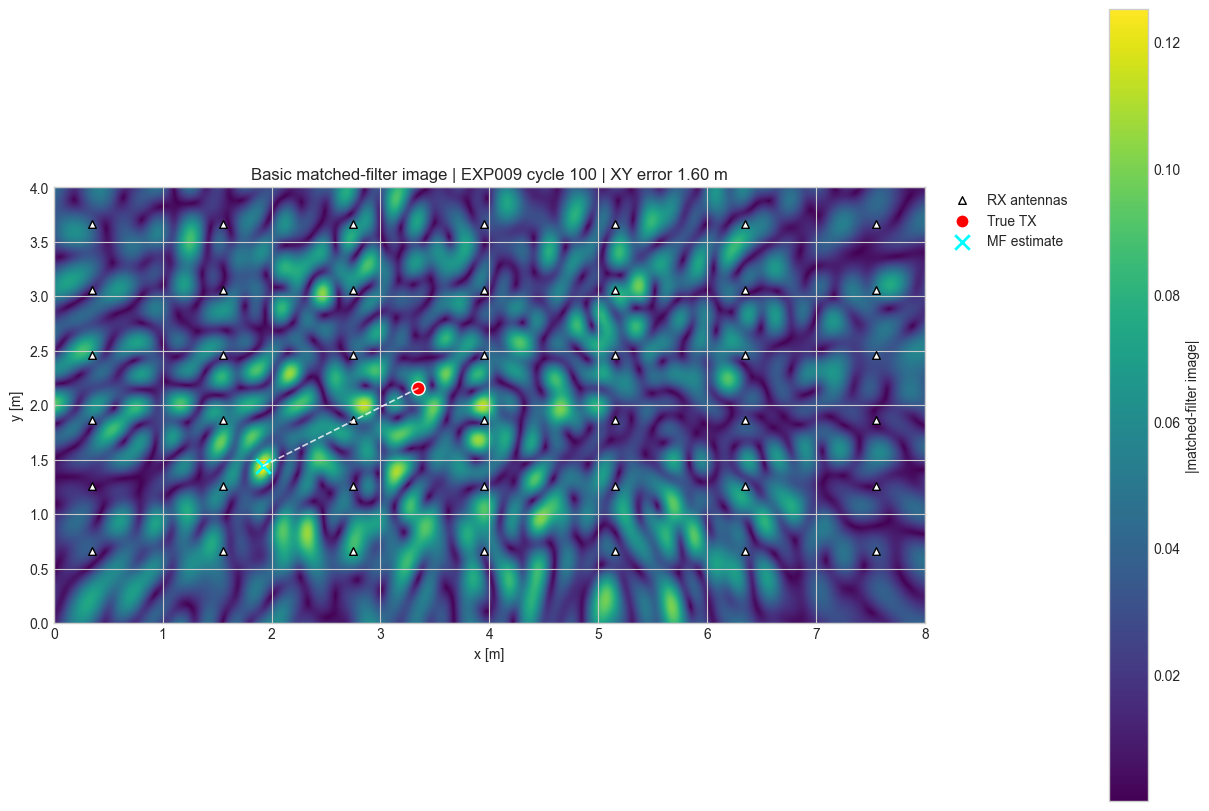

In [41]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
im = ax.imshow(
    np.abs(image),
    origin="lower",
    extent=[grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max()],
    cmap="viridis",
    aspect="equal",
)

ax.scatter(antenna_xyz[:, 0], antenna_xyz[:, 1], marker="^", s=30, c="white", edgecolors="black", label="RX antennas")
ax.scatter([tx_x_true], [tx_y_true], marker="o", s=90, c="red", edgecolors="white", label="True TX")
ax.scatter([tx_x_est], [tx_y_est], marker="x", s=110, c="cyan", linewidths=2.0, label="MF estimate")
ax.plot([tx_x_true, tx_x_est], [tx_y_true, tx_y_est], "w--", lw=1.2, alpha=0.8)

ax.set_title(
    f"Basic matched-filter image | {EXPERIMENT_ID} cycle {SELECTED_CYCLE_ID} | XY error {xy_error_m:.2f} m"
)
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_xlim(float(grid_x.min()), float(grid_x.max()))
ax.set_ylim(float(grid_y.min()), float(grid_y.max()))
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
fig.colorbar(im, ax=ax, label="|matched-filter image|", fraction=0.046, pad=0.04)
plt.show()


In [42]:
sim_tx_x, sim_tx_y = (tx_x_true, tx_y_true) if SIM_TX_XY_M is None else SIM_TX_XY_M
rng = np.random.default_rng(SIM_RANDOM_SEED)

sim_y = simulate_channel(
    tx_x_m=sim_tx_x,
    tx_y_m=sim_tx_y,
    tx_z_m=TX_HEIGHT_M,
    antenna_xyz=antenna_xyz,
    frequency_hz=FREQUENCY_HZ,
    path_loss_exponent=PATH_LOSS_EXPONENT,
    complex_gain=SIM_COMPLEX_GAIN,
    noise_std=SIM_NOISE_STD,
    rng=rng,
)

sim_image = matched_filter_image(
    sim_y,
    antenna_xyz,
    grid_x,
    grid_y,
    tx_z_m=TX_HEIGHT_M,
    frequency_hz=FREQUENCY_HZ,
    path_loss_exponent=PATH_LOSS_EXPONENT,
)

sim_x_est, sim_y_est, sim_peak_value, sim_peak_magnitude = estimate_xy_from_image(grid_x, grid_y, sim_image)
sim_xy_error_m = float(np.hypot(sim_x_est - sim_tx_x, sim_y_est - sim_tx_y))

print(f"Simulated-channel test with path loss alpha={PATH_LOSS_EXPONENT:.2f}")
print(f"Simulated TX XY: ({sim_tx_x:.3f}, {sim_tx_y:.3f}) m")
print(f"Estimated XY:    ({sim_x_est:.3f}, {sim_y_est:.3f}) m")
print(f"XY error:        {sim_xy_error_m:.3f} m")
print(f"Peak image:      {sim_peak_value.real:.4g} {sim_peak_value.imag:+.4g}j")
print(f"Peak magnitude:  {sim_peak_magnitude:.4g}")
assert np.isfinite(sim_xy_error_m)


Simulated-channel test with path loss alpha=1.00
Simulated TX XY: (3.348, 2.157) m
Estimated XY:    (3.360, 2.170) m
XY error:        0.017 m
Peak image:      7.399 +0.4625j
Peak magnitude:  7.414


In [43]:
noisy_rng = np.random.default_rng(SIM_RANDOM_SEED + 1)
noisy_sim_y = simulate_channel(
    tx_x_m=sim_tx_x,
    tx_y_m=sim_tx_y,
    tx_z_m=TX_HEIGHT_M,
    antenna_xyz=antenna_xyz,
    frequency_hz=FREQUENCY_HZ,
    path_loss_exponent=PATH_LOSS_EXPONENT,
    complex_gain=SIM_COMPLEX_GAIN,
    noise_std=SIM_NOISE_STD,
    rng=noisy_rng,
)
noisy_sim_image = matched_filter_image(
    noisy_sim_y,
    antenna_xyz,
    grid_x,
    grid_y,
    tx_z_m=TX_HEIGHT_M,
    frequency_hz=FREQUENCY_HZ,
    path_loss_exponent=PATH_LOSS_EXPONENT,
)
noisy_sim_x_est, noisy_sim_y_est, noisy_sim_peak_value, noisy_sim_peak_magnitude = estimate_xy_from_image(
    grid_x,
    grid_y,
    noisy_sim_image,
)
noisy_sim_xy_error_m = float(np.hypot(noisy_sim_x_est - sim_tx_x, noisy_sim_y_est - sim_tx_y))

print(f"Simulated-channel test with path loss alpha={PATH_LOSS_EXPONENT:.2f}")
print(f"Noise std:       {SIM_NOISE_STD:.3f}")
print(f"Simulated TX XY: ({sim_tx_x:.3f}, {sim_tx_y:.3f}) m")
print(f"Estimated XY:    ({noisy_sim_x_est:.3f}, {noisy_sim_y_est:.3f}) m")
print(f"XY error:        {noisy_sim_xy_error_m:.3f} m")
print(f"Peak image:      {noisy_sim_peak_value.real:.4g} {noisy_sim_peak_value.imag:+.4g}j")
print(f"Peak magnitude:  {noisy_sim_peak_magnitude:.4g}")
assert np.isfinite(noisy_sim_xy_error_m)


Simulated-channel test with path loss alpha=1.00
Noise std:       1.000
Simulated TX XY: (3.348, 2.157) m
Estimated XY:    (2.150, 1.080) m
XY error:        1.611 m
Peak image:      0.9796 +7.345j
Peak magnitude:  7.41


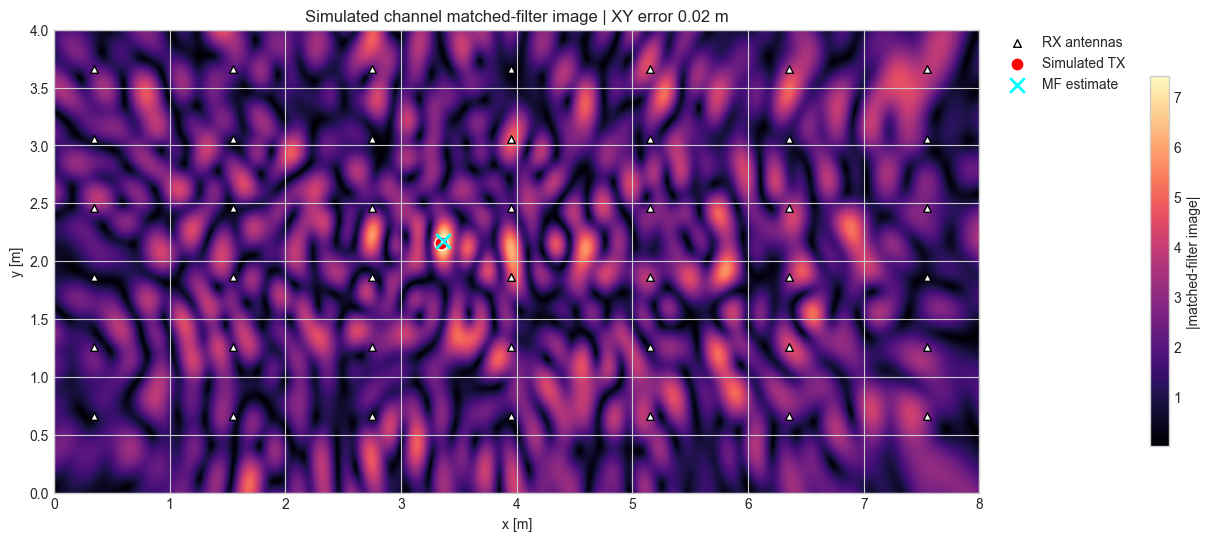

In [44]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)
im = ax.imshow(
    np.abs(sim_image),
    origin="lower",
    extent=[grid_x.min(), grid_x.max(), grid_y.min(), grid_y.max()],
    cmap="magma",
    aspect="equal",
)

ax.scatter(antenna_xyz[:, 0], antenna_xyz[:, 1], marker="^", s=30, c="white", edgecolors="black", label="RX antennas")
ax.scatter([sim_tx_x], [sim_tx_y], marker="o", s=90, c="red", edgecolors="white", label="Simulated TX")
ax.scatter([sim_x_est], [sim_y_est], marker="x", s=110, c="cyan", linewidths=2.0, label="MF estimate")
ax.plot([sim_tx_x, sim_x_est], [sim_tx_y, sim_y_est], "w--", lw=1.2, alpha=0.8)

ax.set_title(f"Simulated channel matched-filter image | XY error {sim_xy_error_m:.2f} m")
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_xlim(float(grid_x.min()), float(grid_x.max()))
ax.set_ylim(float(grid_y.min()), float(grid_y.max()))
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
fig.colorbar(im, ax=ax, label="|matched-filter image|", fraction=0.02, pad=0.02, shrink=0.8)
plt.show()


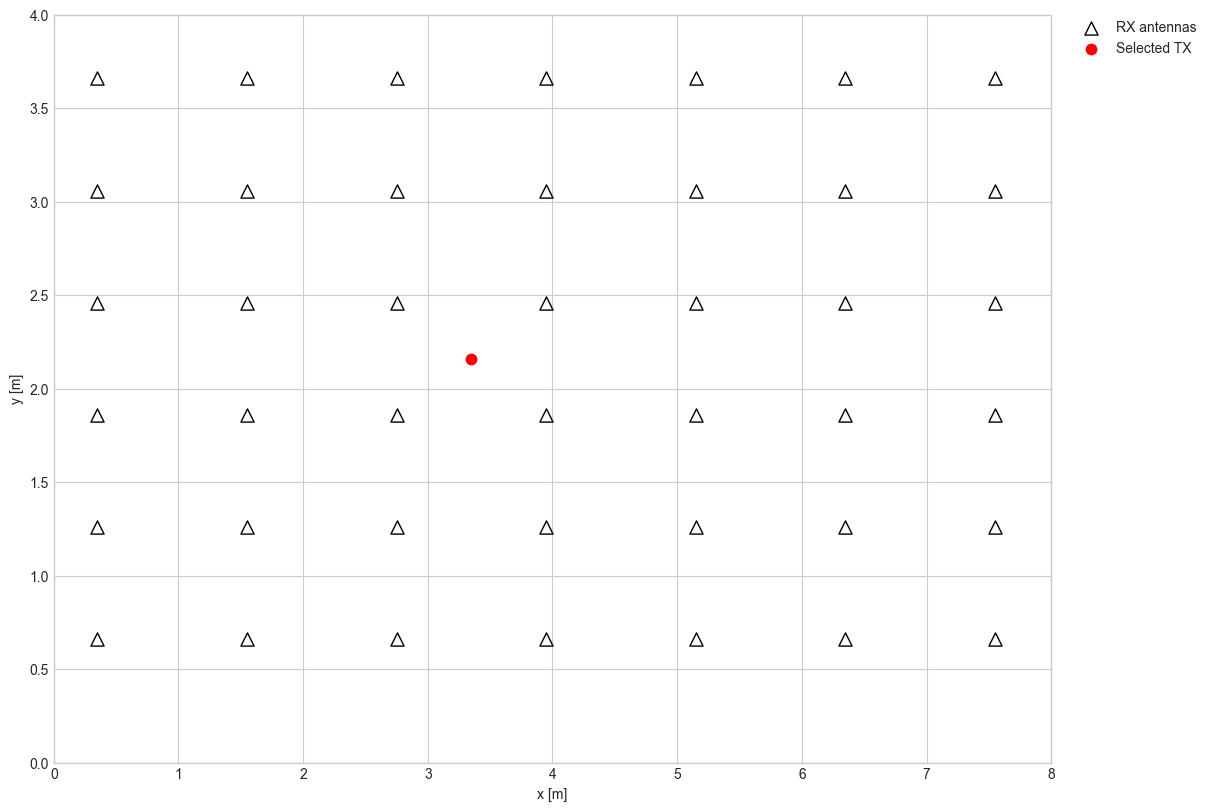

In [45]:
fig, ax = plt.subplots(figsize=(12, 8), constrained_layout=True)


ax.scatter(antenna_xyz[:, 0], antenna_xyz[:, 1], marker="^", s=90, c="white", edgecolors="black", label="RX antennas")
ax.scatter([sim_tx_x], [sim_tx_y], marker="o", s=90, c="red", edgecolors="white", label="Selected TX")

ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_xlim(float(grid_x.min()), float(grid_x.max()))
ax.set_ylim(float(grid_y.min()), float(grid_y.max()))
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1.0), borderaxespad=0.0)
plt.show()

## Notes

- This notebook uses full complex CSI (`csi_real + j*csi_imag`).
- The channel image map includes geometric phase and path loss: `exp(-jkd) / d**PATH_LOSS_EXPONENT`.
- The matched filter is deliberately unnormalized: it forms `sum(conj(image_map) * measured_channel)`.
- No reference calibration or score normalization is applied.
- The search grid spans the whole configured room bounds (`ROOM_X_BOUNDS_M`, `ROOM_Y_BOUNDS_M`).
- The simulated-channel cells test the same path-loss channel model in noiseless and noisy settings.
- 2D localization is enforced by fixing TX height to a known value (`TX_HEIGHT_M`).
